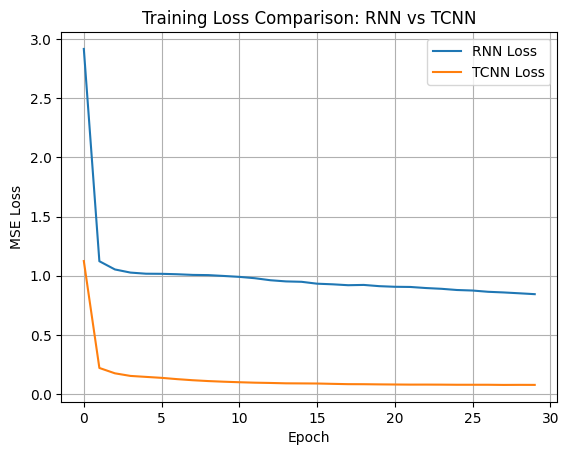

In [1]:
# RNN vs TCNN Example: Synthetic Runoff Forecasting
# Author: ChatGPT for Sensei's CE 5319 Course

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# --- Synthetic Data Generation ---
def generate_runoff_data(n_samples=500, time_steps=30):
    np.random.seed(42)
    rainfall = np.random.gamma(2.0, 2.0, size=(n_samples, time_steps))
    runoff = np.zeros_like(rainfall)
    for i in range(n_samples):
        for t in range(time_steps):
            delay = max(t - 2, 0)  # simple delay effect
            runoff[i, t] = 0.3 * rainfall[i, delay] + 0.05 * np.sum(rainfall[i, max(t-5, 0):t])
    return rainfall, runoff

# Prepare data
X, y = generate_runoff_data()
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # shape: (N, T, 1)
y = torch.tensor(y, dtype=torch.float32)
train_ds = TensorDataset(X, y)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

# --- RNN Model ---
class RNNForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, X.shape[1])

    def forward(self, x):
        _, h_n = self.rnn(x)  # output ignored, h_n is final hidden state
        out = self.fc(h_n.squeeze(0))
        return out

# --- TCNN Model ---
class TCNNForecast(nn.Module):
    def __init__(self, input_size=1, channels=16, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_size, channels, kernel_size, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(channels, 1, kernel_size, padding=1)

    def forward(self, x):
        x = x.transpose(1, 2)  # to (batch, channel, seq)
        x = self.relu(self.conv1(x))
        x = self.conv2(x).squeeze(1)  # (batch, seq)
        return x

# --- Training Loop ---
def train_model(model, train_dl, epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history.append(total_loss / len(train_dl))
    return loss_history

# Instantiate and train both models
rnn_model = RNNForecast()
tcnn_model = TCNNForecast()
rnn_loss = train_model(rnn_model, train_dl)
tcnn_loss = train_model(tcnn_model, train_dl)

# --- Plot Training Loss ---
plt.plot(rnn_loss, label="RNN Loss")
plt.plot(tcnn_loss, label="TCNN Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Comparison: RNN vs TCNN")
plt.legend()
plt.grid(True)
plt.show()


In [2]:
# Markov Chain vs GRU on Synthetic Runoff Data
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# --- Step 1: Generate synthetic rainfall and runoff data ---
def generate_data(n_samples=500, time_steps=30):
    np.random.seed(42)
    rainfall = np.random.gamma(2.0, 2.0, size=(n_samples, time_steps))
    runoff = np.zeros_like(rainfall)
    for i in range(n_samples):
        for t in range(time_steps):
            delay = max(t - 2, 0)
            runoff[i, t] = 0.3 * rainfall[i, delay] + 0.05 * np.sum(rainfall[i, max(t - 5, 0):t])
    return rainfall, runoff

X, y = generate_data()

# --- Step 2: Markov Model (1st-order) ---
def markov_predict(X):
    # Predict runoff at t using rainfall at t-1
    runoff_pred = np.zeros_like(X)
    for i in range(X.shape[0]):
        runoff_pred[i, 1:] = 0.3 * X[i, :-1]  # mimic the delay
    return runoff_pred

markov_pred = markov_predict(X)

# --- Step 3: GRU Model ---
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, X.shape[1])

    def forward(self, x):
        _, h_n = self.rnn(x)
        out = self.fc(h_n.squeeze(0))
        return out

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y_tensor = torch.tensor(y, dtype=torch.float32)
data = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(data, batch_size=32, shuffle=True)

model = GRUForecast()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(30):
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Predict using GRU
model.eval()
with torch.no_grad():
    gru_pred = model(X_tensor).numpy()

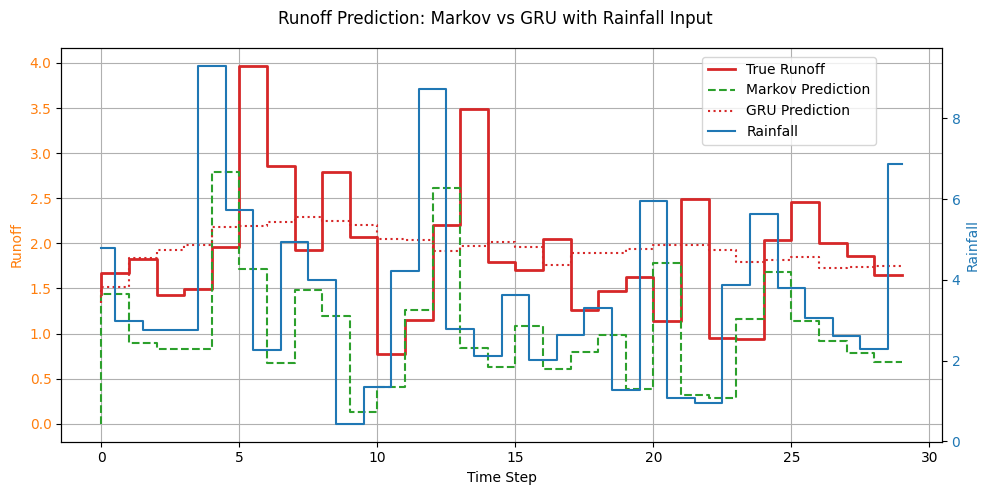

In [3]:
# --- Step 4: Compare predictions with dual y-axes ---
sample_idx = 0
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary y-axis for runoff
ax1.step(range(len(y[sample_idx])),y[sample_idx], label="True Runoff", linewidth=2, color='tab:red')
ax1.step(range(len(markov_pred[sample_idx])),markov_pred[sample_idx], label="Markov Prediction", linestyle='--', color='tab:green')
ax1.step(range(len(gru_pred[sample_idx])),gru_pred[sample_idx], label="GRU Prediction", linestyle=':', color='tab:red')
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Runoff", color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(True)

# Secondary y-axis for rainfall
ax2 = ax1.twinx()
ax2.step(range(len(X[sample_idx])), X[sample_idx], label="Rainfall", where='mid', color='tab:blue', linewidth=1.5)
ax2.set_ylabel("Rainfall", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and legend
fig.suptitle("Runoff Prediction: Markov vs GRU with Rainfall Input", fontsize=12)
fig.legend(loc="upper left", bbox_to_anchor=(0.7, 0.9))
fig.tight_layout()
plt.show()
